- Matthew Benson
- 3/24
- DS 3021
### Final Week 8 Lab Assignment

---
#### Part 1: Questions
1. What makes a model "linear"? "Linear" in what?
Model linearity stems from its parameters or weights being linear. The coefficents, which are usually denoted as B in y = B1 + x are not able to be transformed without comprimising linearity. However, the inputs, denoted as x, x-squared, or log(x), can be transformed without comprimising linearity.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.) There's further explanation at the end of this document, if needed.
Most commonly, when an intercept is involved and a category is dropped, the intercept becomes the mean value and the coefficent represents the difference betwwen the groups. Without an intercept, the coefficent is the average value for the group. Essentially, with an intercept, a representation of the *difference* from the *baseline* group can be seen. Without the intercept, a representation of the *actual mean* of that group can be seen.

3. Can linear regression be used for classification? Explain why, or why not.
Linear regression shouldn't be used for classification because it assumes the number can be any real number. However, we want a value between 0 and 1, and a linear model will likely predict a a number or probability outside of our 0 to 1 range.

4. If you have a high accuracy on training but low on testing, what might be the problem? It also might be you see a pattern in the residuals. 
This is a textbook definition of overfitting, where our model has taken in all noise of the training data and essentially memorized the pattern. WIth residuals, it can be a tell our model is missing a non-linear feature.

5. Review this page: [Non-Linear with Linear](https://inria.github.io/scikit-learn-mooc/python_scripts/linear_regression_non_linear_link.html) What are two ways to incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$?
**Polynomial Features** create new features by adding powers to the features in the model. **Binning** seperates the variable into bins and fits segment pieces for curves in the slope.

6. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?
**Intercept:** A predicted value of our target y when features x of our model equal zero. 
**Slope Coefficent:** Essentially how steep the line is, showing relationships for unit increases in our target variable y
**Dummy Coefficent:** Used as a unit of comparison by telling us the effect of category representation vs continous measuring. Mentioned earlier, the interpretation with a intercept is the difference in average value between the group and whats used for our reference group.

---
#### Part 2: NYC Real Estate Code Notebook
Dataset: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv('Q_1.csv')
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [41]:
# Grouping rows by NYC boroughs and computing averages for 1. Price and 2. Rating
grouped_df= df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean()
grouped_df.sort_values(by="Price", ascending=False)

,Price,Review Scores Rating
Neighbourhood,,
Manhattan,183.664286,91.801496
Staten Island,146.166667,90.843750
Brooklyn,127.747378,92.363497
Queens,96.857233,91.549057
Bronx,75.276498,91.654378


On average, Manhattan is the most expensive borough

In [42]:
#Identifying the most expensive borough
most_e = grouped_df.index[0]
print(most_e)

Bronx


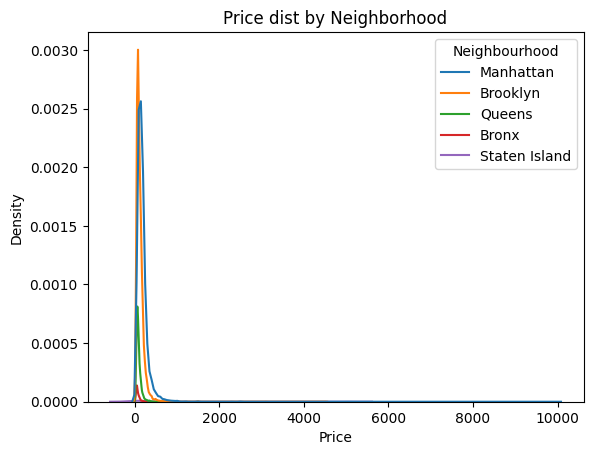

In [43]:
# Creating a KDE plot of price by neighborhood
sns.kdeplot(data=df, x="Price", hue="Neighbourhood")
plt.title("Price dist by Neighborhood")
plt.xlabel("Price")
plt.show()

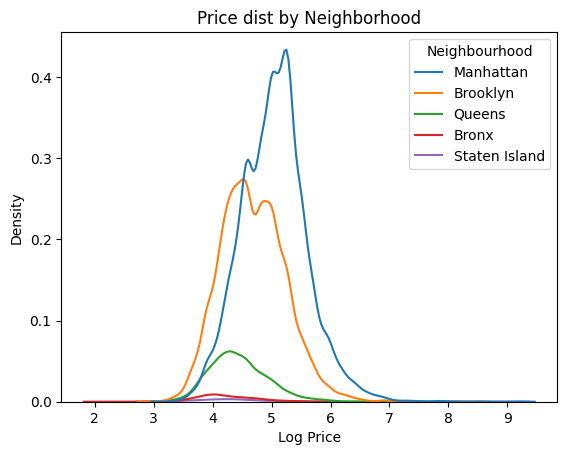

In [44]:
# Creating log price to account for skewed listings
# This makes the distribution easily comparable by compressing larger values of listings
df["log_price"] = np.log(df["Price"])

#Redoing our kde plot with our new log feature\
sns.kdeplot(data=df, x="log_price", hue="Neighbourhood")
plt.title("Price dist by Neighborhood")
plt.xlabel("Log Price")
plt.show()

In doing so, We see a more evenly distributed visual of price listings by neighborhood

In [45]:
#Encoding our dummy variable without dropping to remove the intercept
#Keeping all categories
dummies = pd.get_dummies(df["Neighbourhood"])
dummies.head()

,Bronx,Brooklyn,Manhattan,Queens,Staten Island
0,False,False,True,False,False
1,False,True,False,False,False
2,False,False,True,False,False
3,False,True,False,False,False
4,False,False,True,False,False


In [46]:
# Defining our X and Y for future usage when fitting out model
#But first we must import our most important library
from sklearn.linear_model import LinearRegression

Y = df["Price"]
X = dummies

model = LinearRegression(fit_intercept=False)
model.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
# Veiwing Coefficents and analyzing how they compare to previously
# mode.coef_ acts as as an arrary of modeled numbers when called by Series, While X gives the names

coefficents = pd.Series(model.coef_, index=X.columns)
print(coefficents)

Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64


As we can see, each number is the same which tells us the model is learning the average price listing per borough

In [48]:
# The Comparison Part and turning it into a dataframe
comparison = pd.DataFrame({"Regress Coef": coefficents,
"Mean Price per group": grouped_df["Price"]})

print(comparison)

               Regress Coef  Mean Price per group
Bronx             75.276498             75.276498
Brooklyn         127.747378            127.747378
Manhattan        183.664286            183.664286
Queens            96.857233             96.857233
Staten Island    146.166667            146.166667


See above, it's the same. When regressing a continuous variable on a categorical variable, this time without an intercept, it represents the mean of such categoryu.

---
Question 3

In [49]:
# Repeating part 2 but including an intercept
# To do this we must includ drop_first=True
dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True)
dummies.head()

# We are also going to define X and Y again, ensuring the latest updates
Y = df["Price"]
X = dummies

In [50]:
# Fitting the regression with the intercept
# Like abov, we will be fitting the model again
model = LinearRegression()
model.fit(X, Y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
#passing a series argument to extract coefficents and intercept, printing outcome
coefficents = pd.Series(model.coef_, index=X.columns)
intercept = model.intercept_

print("Intercept:", intercept)
print("Coefficents:", coefficents)

Intercept: 75.27649769585331
Coefficents: Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64


In [52]:
# How to recover our coefficent
# We add the intercept to each coefficent
recovered = coefficents + intercept
recovered["Baseline"] = intercept
recovered

Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Baseline          75.276498
dtype: float64

In conclusion, we hand the creation of dummies differently by adding a drop_first=TRUE, function to avoid multicolinearity. In essence, the intercept represents the average price of our baseline neighborhood. From there, each coefficent represents the difference in price between that specific neighborhood and our set baseline. We can recover our coefficents by adding the intercept to each coefficent.

---
Question 4

In [53]:
# Dummy variable creation for neighbborhood
# Have to drop one since using an intercept
X = pd.get_dummies(df[["Review Scores Rating", "Neighbourhood"]], drop_first=True)
Y = df["Price"]

In [54]:
# creating an 80/20 train, test, split
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

#Fitting our model like before
model = LinearRegression()
model.fit(X_train, Y_train)

#Prediction on our current test set
Y_pred = model.predict(X_test)
print(Y_pred)

[137.58380465 177.68731393 137.58380465 ... 177.68731393 180.1110175
 193.44138713]


In [55]:
# Computing R squared and RMSE 
# importing another addition of sklearn
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))

print("R2:", r2)
print("RMSE", rmse)

R2: 0.045925883817350965
RMSE 140.91821103729345


R2 seems to tell us we have a rather week model while rmse tells us our average error in dollars

In [56]:
# Review Scores Rating coefficents calling to series again
coefficents = pd.Series(model.coef_, index=X.columns)
coefficents["Review Scores Rating"]
coefficents

Review Scores Rating             1.211852
Neighbourhood_Brooklyn          51.555970
Neighbourhood_Manhattan        107.413553
Neighbourhood_Queens            20.198573
Neighbourhood_Staten Island     23.454672
dtype: float64

In [57]:
# Most expensive neighborhood property
inercept = model.intercept_

neighborhood_coefficents = coefficents.filter(like="Neighbourhood")
(neighborhood_coefficents + inercept).sort_values(ascending=False)

Neighbourhood_Manhattan        72.256209
Neighbourhood_Brooklyn         16.398626
Neighbourhood_Staten Island   -11.702672
Neighbourhood_Queens          -14.958771
dtype: float64

Conclusion: When adding the intercept back, we see the borough with the highest estimated price after review scores, showing us how above or below from the baseline each boroughs average property is.

---
Question 5

In [58]:
# Adding property type to our X function
X = pd.get_dummies(df[["Review Scores Rating", "Neighbourhood", "Property Type"]], drop_first=True)
Y = df["Price"]

In [59]:
#Same train test split as before
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

#Fitting our model like before
model = LinearRegression()
model.fit(X_train, Y_train)

#Prediction on our current test set
Y_pred = model.predict(X_test)
print(Y_pred)

[130.43873058 176.19740958 130.43873058 ... 176.19740958 178.5994309
 191.81054816]


In [60]:
#Computing r2 and rsme
r2 = r2_score(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))

print("R2:", r2)
print("RMSE", rmse)

R2: 0.054242713551245325
RMSE 140.30266238276283


A slight increase in model strength can be seen due to more variables

In [61]:
# Review Scores Rating coefficents calling to series again
coefficents = pd.Series(model.coef_, index=X.columns)
coefficents["Review Scores Rating"]
coefficents

Review Scores Rating               1.201011
Neighbourhood_Brooklyn            59.633702
Neighbourhood_Manhattan          121.005520
Neighbourhood_Queens              26.830617
Neighbourhood_Staten Island       15.700974
Property Type_Bed & Breakfast    -28.703920
Property Type_Boat                47.070419
Property Type_Bungalow            83.972440
Property Type_Cabin               12.389621
Property Type_Camper/RV          -13.817125
Property Type_Castle             -41.810548
Property Type_Chalet             -30.237720
Property Type_Condominium         61.907162
Property Type_Dorm               -42.277758
Property Type_House               34.711346
Property Type_Hut               -134.604484
Property Type_Lighthouse         -91.438731
Property Type_Loft                69.891025
Property Type_Other               49.249761
Property Type_Townhouse           44.110768
Property Type_Treehouse           10.325182
Property Type_Villa               33.901468
dtype: float64

In [62]:
# Most expensice property
inercept = model.intercept_

neighborhood_coefficents = coefficents.filter(like="Neighbourhood")
property_coefficents = coefficents.filter(like="Property Type")

#Finding the best and also most expensive combo
neighborhood_price = neighborhood_coefficents + intercept
property_price = property_coefficents + intercept

print("N:")
print(neighborhood_price.sort_values(ascending=False).head())
print("P:")
print(property_price.sort_values(ascending=False).head())

N:
Neighbourhood_Manhattan        196.282018
Neighbourhood_Brooklyn         134.910200
Neighbourhood_Queens           102.107115
Neighbourhood_Staten Island     90.977471
dtype: float64
P:
Property Type_Bungalow       159.248938
Property Type_Loft           145.167522
Property Type_Condominium    137.183660
Property Type_Other          124.526259
Property Type_Boat           122.346917
dtype: float64


The manahattan borough seems to soar as the most expensice, while bungalow seems to show as a clear winner for most expensive predicted property

---
Question 6

Q4 results:
- R2: 0.0459
- RMSE: 140.92
- Review score coef: 1.21
- Most expensive: Manhattan

Q5 results:
- R2: 0.0542
- RMSE: 140.30
- Review score coef: 1.2o
- Most expensive combo: Manhattan and Bungalow

The coefficent changes in part 4 to 5 because the model adds property as an additional variable. In part 4 without property type, the score seems to absorb some of the effect of property type, while in part 5 the coefficent uses it to contribute to the effect or review scores. This makes sense becasue in multiple regression, every coefficent is the effect of a variable, while also holding all others to a constant state.

---
## Part 2: Cars Dataset

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
perform cleaning

In [64]:
df = pd.read_csv('cars_hw.csv')
df.head()
#df.info()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


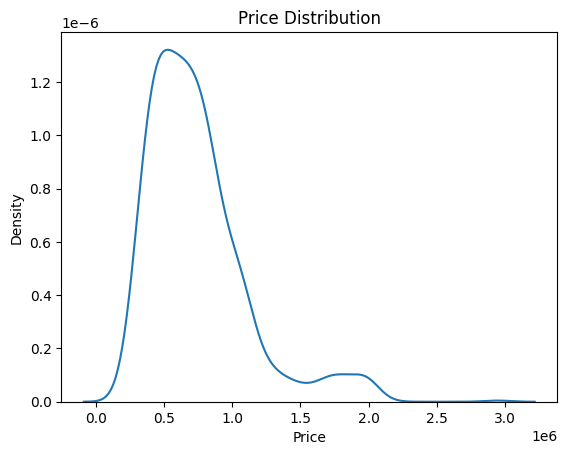

In [65]:
#passing price to a kdeplot to check direction of skew
sns.kdeplot(df["Price"])
plt.title("Price Distribution")
plt.show()

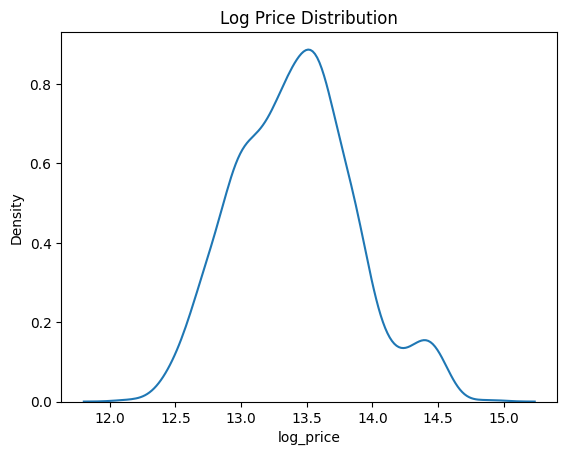

In [66]:
#creating log price
df["log_price"] =  np.log(df["Price"])

#Producing a kde plot of our log price
sns.kdeplot(df["log_price"])
plt.title("Log Price Distribution")
plt.show()

In [67]:
#df.info()
df.describe()

,Unnamed: 0,Make_Year,Mileage_Run,Seating_Capacity,Price,log_price
count,976.000000,976.000000,976.000000,976.000000,9.760000e+02,976.000000
mean,488.500000,2016.963115,41571.195697,5.095287,7.410195e+05,13.411033
std,281.891232,2.818742,24390.995134,0.446224,3.673234e+05,0.450276
min,1.000000,2011.000000,1117.000000,4.000000,1.880000e+05,12.144197
25%,244.750000,2015.000000,22676.750000,5.000000,4.757500e+05,13.072647
50%,488.500000,2017.000000,37570.500000,5.000000,6.665000e+05,13.409795
75%,732.250000,2019.000000,57421.250000,5.000000,8.830000e+05,13.691080
max,976.000000,2022.000000,99495.000000,8.000000,2.941000e+06,14.894260


In conclusion, I didn't find any major issues with data cleanliness, other than a pre-log price skew during the kde plot. Even on a milage kde plot I found mininal skew. To fix the original price skew, I applied a log transformation

---
Question 2

In [68]:
# Summary of price and applying groupby
make_sum = df.groupby("Make")["Price"].describe()
make_sum.sort_values(by="mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
Make,,,,,,,,
MG Motors,35.0,1.869457e+06,1.216611e+05,1589000.0,1786500.0,1848000.0,1978000.0,2019000.0
Kia,8.0,1.614750e+06,1.190567e+05,1369000.0,1579000.0,1628500.0,1705750.0,1741000.0
Jeep,4.0,1.499500e+06,1.525134e+05,1290000.0,1447500.0,1529500.0,1581500.0,1649000.0
Skoda,5.0,1.136000e+06,1.070175e+06,436000.0,466000.0,538000.0,1299000.0,2941000.0
Mahindra,18.0,1.100167e+06,1.755493e+05,796000.0,1037000.0,1094500.0,1157000.0,1465000.0
Tata,23.0,1.055217e+06,5.578305e+05,188000.0,779500.0,869000.0,1552000.0,2100000.0
Nissan,4.0,8.842500e+05,2.895599e+05,475000.0,782500.0,978000.0,1079750.0,1106000.0
Toyota,50.0,8.003400e+05,2.466900e+05,368000.0,526250.0,894000.0,1023000.0,1092000.0
Honda,73.0,7.989726e+05,2.665091e+05,316000.0,581000.0,785000.0,915000.0,1537000.0


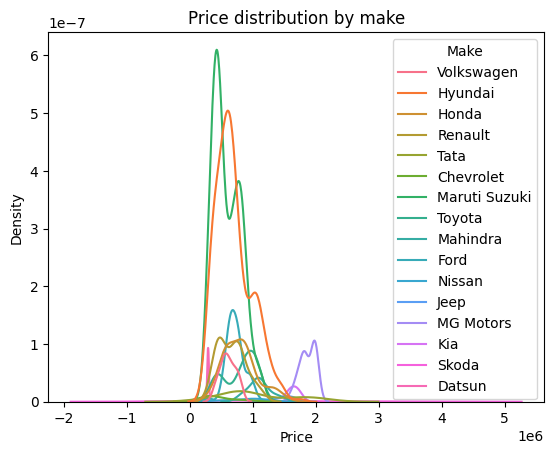

In [69]:
#Creating a KDE plot of price by the car make
sns.kdeplot(df, x="Price", hue="Make")
plt.title("Price distribution by make")
plt.show()

I notice a bit of right-skewed prices, with majority of makes being in the same range except MG Motors

---
Question 3

In [70]:
# importing test train split and splitting 80/20
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Price", "log_price"])
Y = df["Price"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

---
Question 4

In [71]:
# To create a model where we regress numeric values, we first have to identify numeric columns
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

Model 1: Numeric Only

In [72]:
from sklearn .linear_model import LinearRegression

# Training our numeric only model
num_model = LinearRegression()
num_model.fit(X_train[num_cols],Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [73]:
#Evaluating our numeric model with r2, rmse on pred test and pred train predictions
from sklearn.metrics import r2_score, mean_squared_error

#creating our prediction variables
pred_train = num_model.predict(X_train[num_cols])
pred_test = num_model.predict(X_test[num_cols])

#using them to pass to the r2 and rmse tests
train_r2 = r2_score(Y_train, pred_train)
test_r2 = r2_score(Y_test, pred_test)
rmse_test = np.sqrt(mean_squared_error(Y_test, pred_test))

#printing our new values
print("r2:", train_r2)
print("R2", test_r2)
print("Rmse:", rmse_test)

r2: 0.31748308843901385
R2 0.2908824591636343
Rmse: 285188.67185774696


---
Model 2: Categorical

In [74]:
#One hot encoding with the drop first method
X_cat = pd.get_dummies(X[cat_cols], drop_first=True)

#creating train and test variables that match our original set 
cat_train_x = X_cat.loc[X_train.index]
cat_test_x =  X_cat.loc[X_test.index]

In [75]:
#Training stage
cat_model = LinearRegression()
cat_model.fit(cat_train_x, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [76]:
#Evaluation stage, similar to the numerical evaluation structure
pred_test_cat = cat_model.predict(cat_test_x)

cat_r2 = r2_score(Y_test, pred_test_cat)
cat_rmse = np.sqrt(mean_squared_error(Y_test, pred_test_cat))

print("r2:", cat_r2)
print("RMSE:", cat_rmse)

r2: 0.7086843554399442
RMSE: 182791.1060130852


---
Combined Model

In [77]:
#Repeating steps above for dummies, train, and evaluate, just changing variables according to combined model
#dummies
X_combined = pd.get_dummies(X, drop_first=True)

X_train_combined = X_combined.loc[X_train.index]
X_test_combined = X_combined.loc[X_test.index]

In [78]:
#Training the combined model
combined_model = LinearRegression()
combined_model.fit(X_train_combined, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [79]:
# Evaluating the combined model
combined_pred_test = combined_model.predict(X_test_combined)

r2_combined = r2_score(Y_test, combined_pred_test)
rmse_combined = np.sqrt(mean_squared_error(Y_test, combined_pred_test))

print("R2:", r2_combined)
print("rmse:", rmse_combined)

R2: 0.8163910583949119
rmse: 145117.59426198687


---
Comparing Models

**Numeric Model:**

- r2: 0.31748308843901385
- R2 0.2908824591636343
- Rmse: 285188.67185774696

**Categorical Mode:**

- r2: 0.7086843554399442
- RMSE: 182791.1060130852

**Combined model:**

- R2: 0.8163910583949119
- rmse: 145117.59426198687

The combined model performed the best by a long shot

---
Question 5: Polynomial Model

In [80]:
from sklearn.preprocessing import PolynomialFeatures

#up to degree 2
poly = PolynomialFeatures(degree=2)

#Model leanring and application
X_train_poly = poly.fit_transform(X_train[num_cols])
X_test_poly = poly.transform(X_test[num_cols])

In [81]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, Y_train)

#model predictions assigened to variable
pred_poly = poly_model.predict(X_test_poly)

#r2 and rsme
r2_poly = r2_score(Y_test, pred_poly)
rmse_poly = np.sqrt(mean_squared_error(Y_test, pred_poly))

print("R2:", r2_poly)
print("RMSE:", rmse_poly)

R2: 0.30502138788210786
RMSE: 282331.2014343792


i noticed that adjusting the degree usually causes conflicting movment between R-squared and rmse. In some cases, r2 increases, while rmse decreases, and vice versa. When I changed it to 10, it dropped into the negatives, causing overfitting. It's safe to say it doesn't compare very competitivley with my model from 4.

---
Question 6: Predictions and Residuals

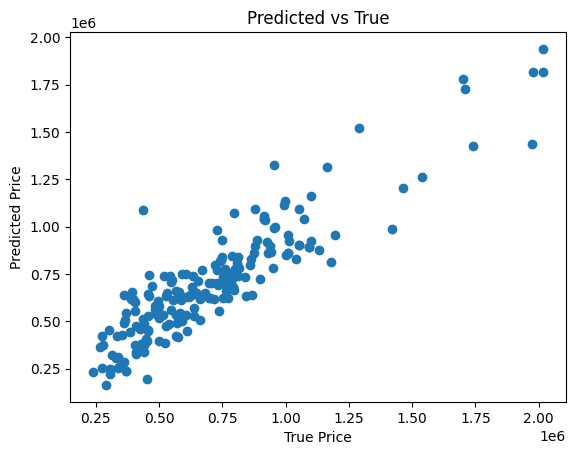

In [82]:
#plotting predicted vs true price
plt.scatter(Y_test, combined_pred_test)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs True")
plt.show()

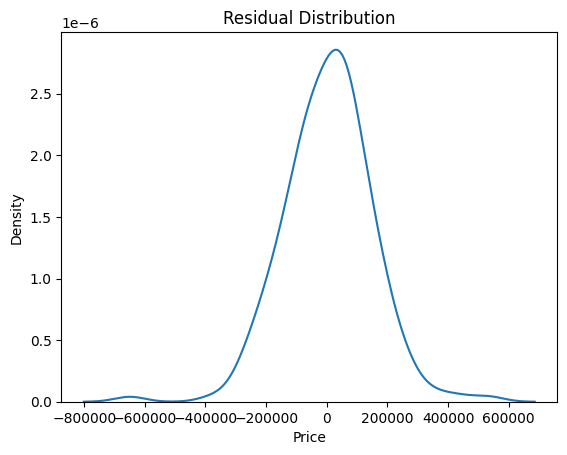

In [83]:
#KDE plotting residuals/errors to determine shape 
residuals = Y_test - combined_pred_test

sns.kdeplot(residuals)
plt.title("Residual Distribution")
plt.show()

- Conclusivly, the plotted points do seem to lie along a diaagnol line meaning the predicted is close to the actual. The plot shows a clear positive trend, with some spread and a few outliers.

- The residual plot shows a bell shaped curve centered near 0 with slight tails and a spread.

- Overall, the model performs decently well but shows some signs of variability with spreas, tails, and some outliers for extreme values.

---
## Part 3

For part three I will be using an air quality dataset of NYC that I found on Kaggle

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [85]:
df = pd.read_csv("airquality.csv")
df.head()

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,179772,640,Boiler Emissions- Total SO2 Emissions,Number per km2,number,UHF42,409.0,Southeast Queens,2015,01/01/2015,0.3,NaN
1,179785,640,Boiler Emissions- Total SO2 Emissions,Number per km2,number,UHF42,209.0,Bensonhurst - Bay Ridge,2015,01/01/2015,1.2,NaN
2,178540,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF42,209.0,Bensonhurst - Bay Ridge,Annual Average 2012,12/01/2011,8.6,NaN
3,178561,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF42,409.0,Southeast Queens,Annual Average 2012,12/01/2011,8.0,NaN
4,823217,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF42,409.0,Southeast Queens,Summer 2022,06/01/2022,6.1,NaN


In [86]:
# Cleaning dataset

df = df.drop_duplicates()
df = df.reset_index(drop=True)

#Converting key columns we need to numeric through pd.to_numeric
df["Data Value"] = pd.to_numeric(df["Data Value"], errors="coerce")
df["Geo Join ID"] = pd.to_numeric(df["Geo Join ID"], errors="coerce")
df["Indicator ID"] = pd.to_numeric(df["Indicator ID"], errors="coerce")

#dropping rowa with missing values in these columns
df = df.dropna(subset=["Data Value", "Geo Join ID", "Indicator ID"])

df.head()

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,179772,640,Boiler Emissions- Total SO2 Emissions,Number per km2,number,UHF42,409.0,Southeast Queens,2015,01/01/2015,0.3,NaN
1,179785,640,Boiler Emissions- Total SO2 Emissions,Number per km2,number,UHF42,209.0,Bensonhurst - Bay Ridge,2015,01/01/2015,1.2,NaN
2,178540,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF42,209.0,Bensonhurst - Bay Ridge,Annual Average 2012,12/01/2011,8.6,NaN
3,178561,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF42,409.0,Southeast Queens,Annual Average 2012,12/01/2011,8.0,NaN
4,823217,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF42,409.0,Southeast Queens,Summer 2022,06/01/2022,6.1,NaN


---
### 2: EDA

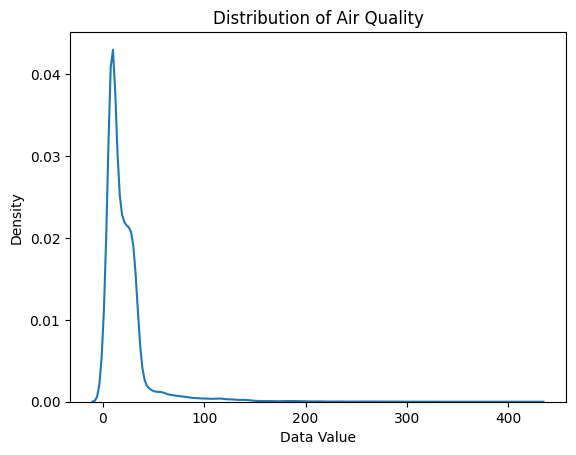

In [87]:
#KDE plot of air quality
sns.kdeplot(df["Data Value"])
plt.title("Distribution of Air Quality")
plt.show()

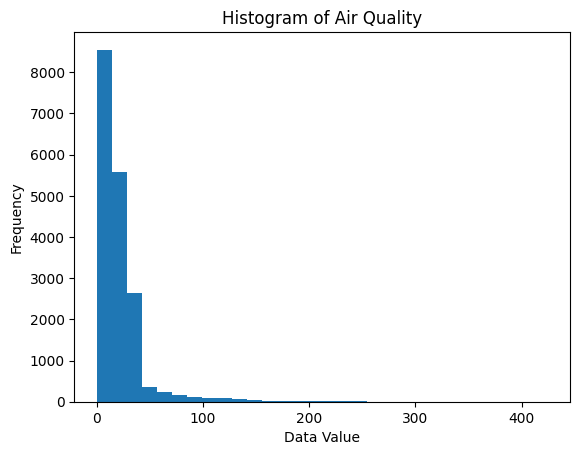

In [88]:
#Hist of air quality
plt.hist(df["Data Value"], bins=30)
plt.title("Histogram of Air Quality")
plt.xlabel("Data Value")
plt.ylabel("Frequency")
plt.show()

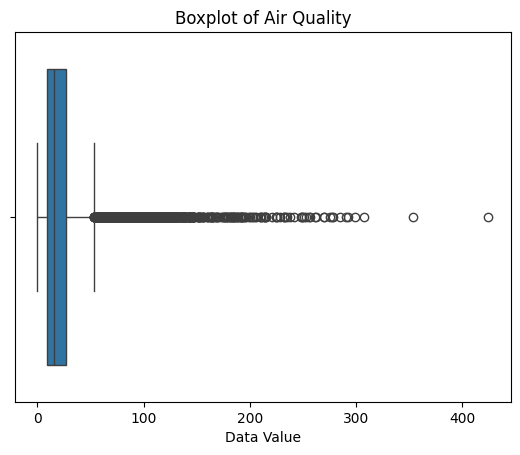

In [89]:
#Box plot of air quality
sns.boxplot(x=df["Data Value"])
plt.title("Boxplot of Air Quality")
plt.show()

---
### 3: Target Selection and Split

In [90]:
# Defining targets and specific features
# Target variable
Y = df["Data Value"]
# predictors
X = df[["Geo Join ID", "Indicator ID"]]

The purpose of using these specific variables is becasue **data value** represents air pollution levele, such as contributing factors like emissions, PM2.5, etc. **Geo Join ID** represents location, giving the model a sense of spacial awarness because different locations have different pollution levels. **Indicator ID** defines the type of measurement and helps the model distinguish by the types of pollution.

In [91]:
# Train test split implementation(80/20)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)



---
### 3.1: Model Building, testing, and RMSE

In [92]:
#Model 1: Linear Regression
model1 = LinearRegression()
model1.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [93]:
# Model 1 prediction plus RMSE
pred1 = model1.predict(X_test)
rmse1 = np.sqrt(mean_squared_error(Y_test, pred1))

print("RMSE1:", rmse1)

RMSE1: 21.591336252210755


In [94]:
# Model 2: adding a non-linear feature by squaring terms and allowing variable complexity to see if it will affect prediction
# Copying our train and test first
X_train2 = X_train.copy()
X_test2 = X_test.copy()

#Squaring them
X_train2["Geo Join ID^2"] = X_train2["Geo Join ID"]**2
X_test2["Geo Join ID^2"] = X_test2["Geo Join ID"]**2

#fitting them
model2 = LinearRegression()
model2.fit(X_train2, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


The reason I chose to square this model is because using a linear model assumes the data is evenly increasing in a straight line, which is far from the case with air quality data. Squuaring these parameters adjusts the flexibility of the model to predict nonlinear relationships within the data.

In [95]:
# Testing model 2
pred2 = model2.predict(X_test2)
rmse2 = np.sqrt(mean_squared_error(Y_test, pred2))

print("RMSE2:", rmse2)

RMSE2: 22.73272092364178


---
### Takeaway and conclusion

This data was cleaned by removing duplicates and converting the three parameters listed above to numeric. After splitting 80/20, I created two models, one using just basic regression like the labs above, and the other, model 2, using squared parameters in hopes the model would capture some of the complexities of the data world. The second model performed slightly better, but not by much. This improvement was due to including the nonlinear feature of squaring, as listed above. Overall, my goal with the model was to provide a basic estimation and prediction of air quality levels.

Had I more time, I would have definitley looked into expanding some of the simple qualities of my model, messed around with post visuals, and tuned the model towards a goal of mine. However I kept it simple as these are still developing concepts to me, and I find it fascinating to actually visualize what your model is seeing in real time.